## Interval-censored init variants (chunked workflow)

This notebook follows the same staging pattern as `example_interval_censored_density_estimator.ipynb`, but focuses on **Stage 1 init knot strategies**:

- `midpoint`
- `uniform_sqrt_n`
- `uniform_n`
- `turnbull`

For `inspection_uniform` data, we run:
1. Stage 1 (Init) with Optuna-CV for each strategy
2. Stage 2C (CV-oversmooth) starting from each Stage 1 fit
3. Side-by-side diagnostics and density plots

We also include a compact Stage 1 comparison on `current_status_uniform` data to highlight where Turnbull knot behavior can differ.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.censoring import (
    IntervalCensoredInitTuner,
    IntervalCensoredCVOversmoothEMTuner,
    incomplete_loglik_interval,
    interval_censor_inspection_uniform,
    interval_censor_current_status_uniform,
    kl_divergence,
)
from haldensity.utils.dgp.truncated_gmm import TruncatedGMM

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) Generate synthetic interval-censored datasets
np.random.seed(42)
n = 300

sampler = TruncatedGMM(
    components=[
        {"mean": 0.2, "std": 0.08, "lower": 0.0, "upper": 1.0},
        {"mean": 0.55, "std": 0.10, "lower": 0.0, "upper": 1.0},
        {"mean": 0.85, "std": 0.05, "lower": 0.0, "upper": 1.0},
    ],
    weights=[0.33, 0.34, 0.33],
)

t_event = sampler.generate_samples(n)

# Main dataset for staged pipeline
inspection_data = interval_censor_inspection_uniform(t_event, n_inspections=3, random_state=42)

# Extra dataset to check strategy behavior under current-status censoring
current_status_data = interval_censor_current_status_uniform(t_event, random_state=42)

print(f"n={n}")
print(f"inspection_uniform mean width: {(inspection_data['R'] - inspection_data['L']).mean():.3f}")
print(f"current_status_uniform mean width: {(current_status_data['R'] - current_status_data['L']).mean():.3f}")
display(inspection_data.head())

n=300
inspection_uniform mean width: 0.417
current_status_uniform mean width: 0.685


,L,R
0,0.438878,0.773956
1,0.697368,0.975622
2,0.128114,0.761140
3,0.450386,0.926765
4,0.000000,0.443414


In [3]:
# 2) Shared config + helpers (same tuner pattern as the interval notebook)
grid = np.linspace(0.01, 0.99, 250)
grid_kl = np.linspace(0.001, 0.999, 4000)
true_pdf_fn = sampler.compute_density

cv_folds_stage1 = 5
n_trials_stage1 = 40
cv_folds_stage2c = 5
n_trials_stage2c = 20


def fit_stage1_init(data: pd.DataFrame, strategy: str):
    tuner = IntervalCensoredInitTuner(
        data=data,
        cv_folds=cv_folds_stage1,
        random_state=42,
        n_grid_points=120,
        init_knot_strategy=strategy,
        init_turnbull_tol=1e-6,
        silent=True,
    )
    tuner.param_overrides = {
        "basis_order": [2],
        "norm_constraint": {"low": 1.0, "high": 2000.0, "log": True},
    }
    return tuner.optimize(n_trials=n_trials_stage1)


def fit_stage2c(data: pd.DataFrame, stage1_estimator):
    tuner = IntervalCensoredCVOversmoothEMTuner(
        data,
        stage1_estimator=stage1_estimator,
        cv_folds=cv_folds_stage2c,
        oversmooth_factors=[0.1, 1.0],
        em_norm_factors=[1.0, 5.0],
        em_m_imputations=100,
        em_max_em_iter=20,
        em_tol=1e-1,
        n_grid_points=120,
        random_state=42,
        silent=True,
    )
    return tuner.optimize(n_trials=n_trials_stage2c)


def summarize_estimator(est, data: pd.DataFrame):
    return {
        "ll": float(incomplete_loglik_interval(est, data)),
        "kl": float(kl_divergence(true_pdf_fn, grid_kl, est.get_density_at_points(grid_kl))),
        "n_total_grid_points": int(len(getattr(est, "_grid_points_hal", []))),
        "n_selected_knots": int(est.get_results()["n_selected_knots"]),
        "density": est.get_density_at_points(grid),
    }

In [4]:
# 3A) Stage 1 init on inspection_uniform: midpoint
init_midpoint = fit_stage1_init(inspection_data, "midpoint")
midpoint_s1 = summarize_estimator(init_midpoint.estimator, inspection_data)

print("Stage 1 midpoint")
print("  best_params:", init_midpoint.best_params)
print("  n_total_grid_points:", midpoint_s1["n_total_grid_points"])
print("  n_selected_knots:", midpoint_s1["n_selected_knots"])
print(f"  ll={midpoint_s1['ll']:.4f}, kl={midpoint_s1['kl']:.6f}")

Stage 1 midpoint
  best_params: {'norm_constraint': 275.1605550135094, 'basis_order': 2}
  n_total_grid_points: 302
  n_selected_knots: 148
  ll=-300.4172, kl=0.113163


In [5]:
# 3B) Stage 1 init on inspection_uniform: uniform_sqrt_n
init_uniform_sqrt_n = fit_stage1_init(inspection_data, "uniform_sqrt_n")
uniform_sqrt_n_s1 = summarize_estimator(init_uniform_sqrt_n.estimator, inspection_data)

print("Stage 1 uniform_sqrt_n")
print("  best_params:", init_uniform_sqrt_n.best_params)
print("  n_total_grid_points:", uniform_sqrt_n_s1["n_total_grid_points"])
print("  n_selected_knots:", uniform_sqrt_n_s1["n_selected_knots"])
print(f"  ll={uniform_sqrt_n_s1['ll']:.4f}, kl={uniform_sqrt_n_s1['kl']:.6f}")

Stage 1 uniform_sqrt_n
  best_params: {'norm_constraint': 289.0806033794828, 'basis_order': 2}
  n_total_grid_points: 18
  n_selected_knots: 15
  ll=-300.3750, kl=0.112527


### 3C) Stage 1 init on inspection_uniform: uniform_n

In [6]:
init_uniform_n = fit_stage1_init(inspection_data, "uniform_n")
uniform_n_s1 = summarize_estimator(init_uniform_n.estimator, inspection_data)

print("Stage 1 uniform_n")
print("  best_params:", init_uniform_n.best_params)
print("  n_total_grid_points:", uniform_n_s1["n_total_grid_points"])
print("  n_selected_knots:", uniform_n_s1["n_selected_knots"])
print(f"  ll={uniform_n_s1['ll']:.4f}, kl={uniform_n_s1['kl']:.6f}")

Stage 1 uniform_n
  best_params: {'norm_constraint': 277.8334398556898, 'basis_order': 2}
  n_total_grid_points: 300
  n_selected_knots: 136
  ll=-300.4102, kl=0.113085


### 3D) Stage 1 init on inspection_uniform: turnbull

In [7]:
init_turnbull = fit_stage1_init(inspection_data, "turnbull")
turnbull_s1 = summarize_estimator(init_turnbull.estimator, inspection_data)

print("Stage 1 turnbull")
print("  best_params:", init_turnbull.best_params)
print("  n_total_grid_points:", turnbull_s1["n_total_grid_points"])
print("  n_internal_candidate_knots:", max(0, turnbull_s1["n_total_grid_points"] - 2))
print("  n_selected_knots:", turnbull_s1["n_selected_knots"])
print(f"  ll={turnbull_s1['ll']:.4f}, kl={turnbull_s1['kl']:.6f}")

Stage 1 turnbull
  best_params: {'norm_constraint': 267.8097532427882, 'basis_order': 2}
  n_total_grid_points: 45
  n_internal_candidate_knots: 43
  n_selected_knots: 36
  ll=-300.3887, kl=0.112390


In [8]:
# Stage 1 summary table (inspection_uniform)
stage1_inspection = pd.DataFrame(
    [
        {
            "strategy": "midpoint",
            **{k: v for k, v in midpoint_s1.items() if k != "density"},
        },
        {
            "strategy": "uniform_sqrt_n",
            **{k: v for k, v in uniform_sqrt_n_s1.items() if k != "density"},
        },
        {
            "strategy": "uniform_n",
            **{k: v for k, v in uniform_n_s1.items() if k != "density"},
        },
        {
            "strategy": "turnbull",
            **{k: v for k, v in turnbull_s1.items() if k != "density"},
        },
    ]
)

display(stage1_inspection.sort_values("kl").reset_index(drop=True))

,strategy,ll,kl,n_total_grid_points,n_selected_knots
0,turnbull,-300.388736,0.112390,45,36
1,uniform_sqrt_n,-300.375037,0.112527,18,15
2,uniform_n,-300.410157,0.113085,300,136
3,midpoint,-300.417229,0.113163,302,148


### 4) Stage 2C (CV-oversmooth) after each Stage 1 initializer

In [9]:
em_midpoint_2c = fit_stage2c(inspection_data, init_midpoint.estimator)
em_midpoint_2c_s = summarize_estimator(em_midpoint_2c.estimator, inspection_data)

print("Stage 2C from midpoint")
print("  best_params:", em_midpoint_2c.best_params)
print("  n_selected_knots:", em_midpoint_2c_s["n_selected_knots"])
print(f"  ll={em_midpoint_2c_s['ll']:.4f}, kl={em_midpoint_2c_s['kl']:.6f}")

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Stage 2C from midpoint
  best_params: {'oversmooth_factor': 0.3409197819018639, 'em_norm_factor': 4.880764038851141}
  n_selected_knots: 82
  ll=-292.7256, kl=0.008896


In [10]:
em_uniform_sqrt_n_2c = fit_stage2c(inspection_data, init_uniform_sqrt_n.estimator)
em_uniform_sqrt_n_2c_s = summarize_estimator(em_uniform_sqrt_n_2c.estimator, inspection_data)

print("Stage 2C from uniform_sqrt_n")
print("  best_params:", em_uniform_sqrt_n_2c.best_params)
print("  n_selected_knots:", em_uniform_sqrt_n_2c_s["n_selected_knots"])
print(f"  ll={em_uniform_sqrt_n_2c_s['ll']:.4f}, kl={em_uniform_sqrt_n_2c_s['kl']:.6f}")

Stage 2C from uniform_sqrt_n
  best_params: {'oversmooth_factor': 0.6410035105688879, 'em_norm_factor': 3.832290311184182}
  n_selected_knots: 9
  ll=-293.2416, kl=0.015287


In [11]:
em_uniform_n_2c = fit_stage2c(inspection_data, init_uniform_n.estimator)
em_uniform_n_2c_s = summarize_estimator(em_uniform_n_2c.estimator, inspection_data)

print("Stage 2C from uniform_n")
print("  best_params:", em_uniform_n_2c.best_params)
print("  n_selected_knots:", em_uniform_n_2c_s["n_selected_knots"])
print(f"  ll={em_uniform_n_2c_s['ll']:.4f}, kl={em_uniform_n_2c_s['kl']:.6f}")

Stage 2C from uniform_n
  best_params: {'oversmooth_factor': 0.8924723799477083, 'em_norm_factor': 4.160459702346537}
  n_selected_knots: 138
  ll=-292.1761, kl=0.009584


In [12]:
em_turnbull_2c = fit_stage2c(inspection_data, init_turnbull.estimator)
em_turnbull_2c_s = summarize_estimator(em_turnbull_2c.estimator, inspection_data)

print("Stage 2C from turnbull")
print("  best_params:", em_turnbull_2c.best_params)
print("  n_selected_knots:", em_turnbull_2c_s["n_selected_knots"])
print(f"  ll={em_turnbull_2c_s['ll']:.4f}, kl={em_turnbull_2c_s['kl']:.6f}")

Stage 2C from turnbull
  best_params: {'oversmooth_factor': 0.9725833997090793, 'em_norm_factor': 3.040259481684187}
  n_selected_knots: 28
  ll=-293.0502, kl=0.009291


In [13]:
# Stage 2C summary table (inspection_uniform)
stage2c_inspection = pd.DataFrame(
    [
        {
            "strategy": "midpoint",
            "best_oversmooth_factor": float(em_midpoint_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(em_midpoint_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in em_midpoint_2c_s.items() if k != "density"},
        },
        {
            "strategy": "uniform_sqrt_n",
            "best_oversmooth_factor": float(em_uniform_sqrt_n_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(em_uniform_sqrt_n_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in em_uniform_sqrt_n_2c_s.items() if k != "density"},
        },
        {
            "strategy": "uniform_n",
            "best_oversmooth_factor": float(em_uniform_n_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(em_uniform_n_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in em_uniform_n_2c_s.items() if k != "density"},
        },
        {
            "strategy": "turnbull",
            "best_oversmooth_factor": float(em_turnbull_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(em_turnbull_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in em_turnbull_2c_s.items() if k != "density"},
        },
    ]
)

display(stage2c_inspection.sort_values("kl").reset_index(drop=True))

,strategy,best_oversmooth_factor,best_em_norm_factor,ll,kl,n_total_grid_points,n_selected_knots
0,midpoint,0.340920,4.880764,-292.725583,0.008896,82,82
1,turnbull,0.972583,3.040259,-293.050229,0.009291,28,28
2,uniform_n,0.892472,4.160460,-292.176092,0.009584,138,138
3,uniform_sqrt_n,0.641004,3.832290,-293.241550,0.015287,9,9


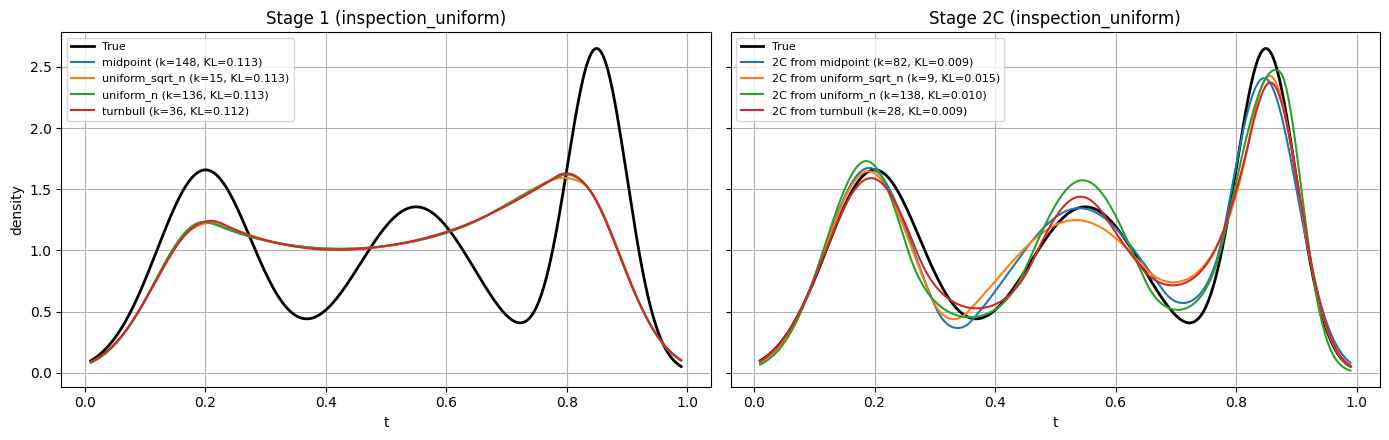

In [14]:
# Density comparison: Stage 1 vs Stage 2C by initializer
true_density = sampler.compute_density(grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

ax = axes[0]
ax.plot(grid, true_density, "k-", lw=2, label="True")
ax.plot(grid, midpoint_s1["density"], lw=1.5, label=f"midpoint (k={midpoint_s1['n_selected_knots']}, KL={midpoint_s1['kl']:.3f})")
ax.plot(grid, uniform_sqrt_n_s1["density"], lw=1.5, label=f"uniform_sqrt_n (k={uniform_sqrt_n_s1['n_selected_knots']}, KL={uniform_sqrt_n_s1['kl']:.3f})")
ax.plot(grid, uniform_n_s1["density"], lw=1.5, label=f"uniform_n (k={uniform_n_s1['n_selected_knots']}, KL={uniform_n_s1['kl']:.3f})")
ax.plot(grid, turnbull_s1["density"], lw=1.5, label=f"turnbull (k={turnbull_s1['n_selected_knots']}, KL={turnbull_s1['kl']:.3f})")
ax.set_title("Stage 1 (inspection_uniform)")
ax.set_xlabel("t")
ax.set_ylabel("density")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(grid, true_density, "k-", lw=2, label="True")
ax.plot(grid, em_midpoint_2c_s["density"], lw=1.5, label=f"2C from midpoint (k={em_midpoint_2c_s['n_selected_knots']}, KL={em_midpoint_2c_s['kl']:.3f})")
ax.plot(grid, em_uniform_sqrt_n_2c_s["density"], lw=1.5, label=f"2C from uniform_sqrt_n (k={em_uniform_sqrt_n_2c_s['n_selected_knots']}, KL={em_uniform_sqrt_n_2c_s['kl']:.3f})")
ax.plot(grid, em_uniform_n_2c_s["density"], lw=1.5, label=f"2C from uniform_n (k={em_uniform_n_2c_s['n_selected_knots']}, KL={em_uniform_n_2c_s['kl']:.3f})")
ax.plot(grid, em_turnbull_2c_s["density"], lw=1.5, label=f"2C from turnbull (k={em_turnbull_2c_s['n_selected_knots']}, KL={em_turnbull_2c_s['kl']:.3f})")
ax.set_title("Stage 2C (inspection_uniform)")
ax.set_xlabel("t")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Stage 1 (current_status_uniform)


,strategy,ll,kl,n_total_grid_points,n_selected_knots
0,uniform_sqrt_n,-135.914084,0.183603,18,2
1,turnbull,-135.909663,0.183795,41,1
2,midpoint,-135.920680,0.183849,302,1
3,uniform_n,-135.923386,0.183914,300,4


Turnbull knot counts (current_status_uniform):
  n_total_grid_points: 41
  n_internal_candidate_knots: 39
  n_selected_knots: 1
Stage 2C (current_status_uniform)


,strategy,best_oversmooth_factor,best_em_norm_factor,ll,kl,n_total_grid_points,n_selected_knots
0,uniform_n,0.682722,1.497535,-133.535472,0.179541,4,4
1,midpoint,0.682722,1.497535,-133.535487,0.179543,1,1
2,uniform_sqrt_n,0.682722,1.497535,-133.523471,0.179603,2,2
3,turnbull,0.682722,1.497535,-133.522474,0.179647,1,1


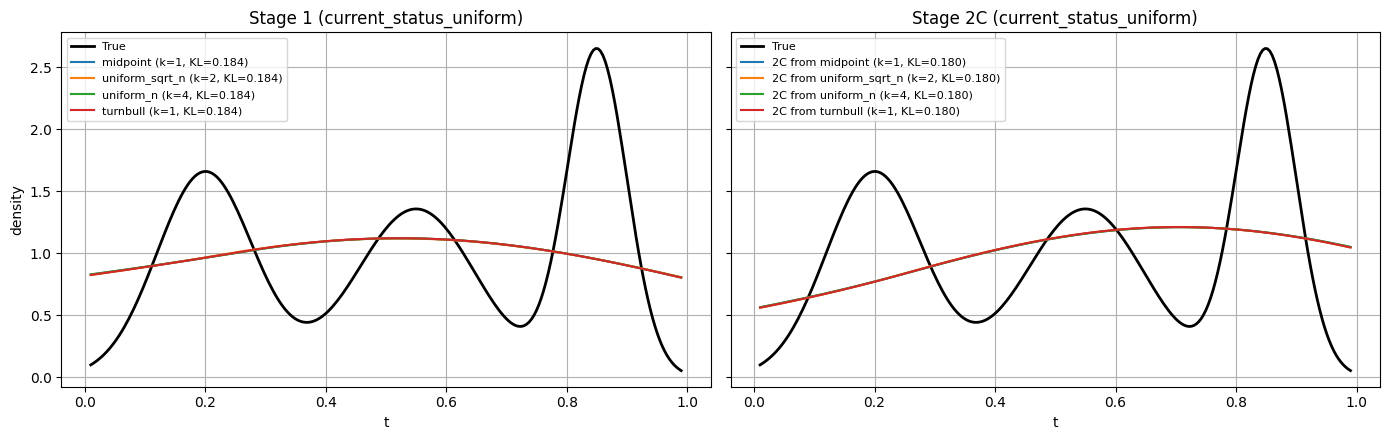

In [15]:
# 5) Current-status case: same pipeline as inspection_uniform

# Stage 1 (Init) for each strategy
cs_midpoint = fit_stage1_init(current_status_data, "midpoint")
cs_uniform_sqrt_n = fit_stage1_init(current_status_data, "uniform_sqrt_n")
cs_uniform_n = fit_stage1_init(current_status_data, "uniform_n")
cs_turnbull = fit_stage1_init(current_status_data, "turnbull")

cs_midpoint_s = summarize_estimator(cs_midpoint.estimator, current_status_data)
cs_uniform_sqrt_n_s = summarize_estimator(cs_uniform_sqrt_n.estimator, current_status_data)
cs_uniform_n_s = summarize_estimator(cs_uniform_n.estimator, current_status_data)
cs_turnbull_s = summarize_estimator(cs_turnbull.estimator, current_status_data)

cs_stage1 = pd.DataFrame(
    [
        {"strategy": "midpoint", **{k: v for k, v in cs_midpoint_s.items() if k != "density"}},
        {"strategy": "uniform_sqrt_n", **{k: v for k, v in cs_uniform_sqrt_n_s.items() if k != "density"}},
        {"strategy": "uniform_n", **{k: v for k, v in cs_uniform_n_s.items() if k != "density"}},
        {"strategy": "turnbull", **{k: v for k, v in cs_turnbull_s.items() if k != "density"}},
    ]
)

print("Stage 1 (current_status_uniform)")
display(cs_stage1.sort_values("kl").reset_index(drop=True))

print("Turnbull knot counts (current_status_uniform):")
print("  n_total_grid_points:", cs_turnbull_s["n_total_grid_points"])
print("  n_internal_candidate_knots:", max(0, cs_turnbull_s["n_total_grid_points"] - 2))
print("  n_selected_knots:", cs_turnbull_s["n_selected_knots"])

# Stage 2C (CV-oversmooth) after each initializer
cs_em_midpoint_2c = fit_stage2c(current_status_data, cs_midpoint.estimator)
cs_em_uniform_sqrt_n_2c = fit_stage2c(current_status_data, cs_uniform_sqrt_n.estimator)
cs_em_uniform_n_2c = fit_stage2c(current_status_data, cs_uniform_n.estimator)
cs_em_turnbull_2c = fit_stage2c(current_status_data, cs_turnbull.estimator)

cs_em_midpoint_2c_s = summarize_estimator(cs_em_midpoint_2c.estimator, current_status_data)
cs_em_uniform_sqrt_n_2c_s = summarize_estimator(cs_em_uniform_sqrt_n_2c.estimator, current_status_data)
cs_em_uniform_n_2c_s = summarize_estimator(cs_em_uniform_n_2c.estimator, current_status_data)
cs_em_turnbull_2c_s = summarize_estimator(cs_em_turnbull_2c.estimator, current_status_data)

cs_stage2c = pd.DataFrame(
    [
        {
            "strategy": "midpoint",
            "best_oversmooth_factor": float(cs_em_midpoint_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(cs_em_midpoint_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in cs_em_midpoint_2c_s.items() if k != "density"},
        },
        {
            "strategy": "uniform_sqrt_n",
            "best_oversmooth_factor": float(cs_em_uniform_sqrt_n_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(cs_em_uniform_sqrt_n_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in cs_em_uniform_sqrt_n_2c_s.items() if k != "density"},
        },
        {
            "strategy": "uniform_n",
            "best_oversmooth_factor": float(cs_em_uniform_n_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(cs_em_uniform_n_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in cs_em_uniform_n_2c_s.items() if k != "density"},
        },
        {
            "strategy": "turnbull",
            "best_oversmooth_factor": float(cs_em_turnbull_2c.best_params["oversmooth_factor"]),
            "best_em_norm_factor": float(cs_em_turnbull_2c.best_params["em_norm_factor"]),
            **{k: v for k, v in cs_em_turnbull_2c_s.items() if k != "density"},
        },
    ]
)

print("Stage 2C (current_status_uniform)")
display(cs_stage2c.sort_values("kl").reset_index(drop=True))

# Density plots
true_density = sampler.compute_density(grid)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

ax = axes[0]
ax.plot(grid, true_density, "k-", lw=2, label="True")
ax.plot(grid, cs_midpoint_s["density"], lw=1.5, label=f"midpoint (k={cs_midpoint_s['n_selected_knots']}, KL={cs_midpoint_s['kl']:.3f})")
ax.plot(grid, cs_uniform_sqrt_n_s["density"], lw=1.5, label=f"uniform_sqrt_n (k={cs_uniform_sqrt_n_s['n_selected_knots']}, KL={cs_uniform_sqrt_n_s['kl']:.3f})")
ax.plot(grid, cs_uniform_n_s["density"], lw=1.5, label=f"uniform_n (k={cs_uniform_n_s['n_selected_knots']}, KL={cs_uniform_n_s['kl']:.3f})")
ax.plot(grid, cs_turnbull_s["density"], lw=1.5, label=f"turnbull (k={cs_turnbull_s['n_selected_knots']}, KL={cs_turnbull_s['kl']:.3f})")
ax.set_title("Stage 1 (current_status_uniform)")
ax.set_xlabel("t")
ax.set_ylabel("density")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(grid, true_density, "k-", lw=2, label="True")
ax.plot(grid, cs_em_midpoint_2c_s["density"], lw=1.5, label=f"2C from midpoint (k={cs_em_midpoint_2c_s['n_selected_knots']}, KL={cs_em_midpoint_2c_s['kl']:.3f})")
ax.plot(grid, cs_em_uniform_sqrt_n_2c_s["density"], lw=1.5, label=f"2C from uniform_sqrt_n (k={cs_em_uniform_sqrt_n_2c_s['n_selected_knots']}, KL={cs_em_uniform_sqrt_n_2c_s['kl']:.3f})")
ax.plot(grid, cs_em_uniform_n_2c_s["density"], lw=1.5, label=f"2C from uniform_n (k={cs_em_uniform_n_2c_s['n_selected_knots']}, KL={cs_em_uniform_n_2c_s['kl']:.3f})")
ax.plot(grid, cs_em_turnbull_2c_s["density"], lw=1.5, label=f"2C from turnbull (k={cs_em_turnbull_2c_s['n_selected_knots']}, KL={cs_em_turnbull_2c_s['kl']:.3f})")
ax.set_title("Stage 2C (current_status_uniform)")
ax.set_xlabel("t")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Notes

- Stage 1 uses `IntervalCensoredInitTuner.optimize(...)`, i.e., **Optuna + CV**, matching the pattern in `example_interval_censored_density_estimator.ipynb`.
- We intentionally split each initializer into separate cells so each fit can be inspected independently.
- Turnbull strategy reports both total basis grid points and selected knots; this often differs between `inspection_uniform` and `current_status_uniform`.